# 🤖 Predicción y Análisis de Rendimiento Fotovoltaico con SARIMAX

En este cuaderno avanzamos del preprocesamiento al **Modelado Predictivo** y **Análisis de Eficiencia**. El objetivo es doble:
1. Predecir la generación de potencia utilizando un modelo de series temporales con variables exógenas (SARIMAX).
2. Comparar los datos teóricos con la realidad operativa, simulando pérdidas físicas (temperatura) y limitaciones técnicas (inversores).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm


# Carga del dataset preprocesado
df = pd.read_csv('pvgis_graus_2013_2023_hourly_modificado.csv')
df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time").sort_index()

pd.options.display.float_format = '{:,.2f}'.format
df.head(10)

,P,G(i),H_sun,T2m,WS10m
time,,,,,
2013-01-01 00:10:00,0.00,0.00,0.00,-1.33,1.79
2013-01-01 01:10:00,0.00,0.00,0.00,-1.16,1.66
2013-01-01 02:10:00,0.00,0.00,0.00,-0.34,1.45
2013-01-01 03:10:00,0.00,0.00,0.00,0.33,1.45
2013-01-01 04:10:00,0.00,0.00,0.00,0.90,1.24
2013-01-01 05:10:00,0.00,0.00,0.00,1.56,0.97
2013-01-01 06:10:00,0.00,0.00,0.00,1.93,0.83
2013-01-01 07:10:00,0.00,0.00,0.00,2.37,0.62
2013-01-01 08:10:00,"274,435.20",233.99,5.72,2.50,0.69


# 0. Validación de Estacionariedad: Test de Dickey-Fuller Aumentado (ADF)

En esta fase del cuaderno, realizamos un **Diagnóstico Estadístico** crítico antes de pasar al modelado. El objetivo es verificar la estabilidad de las series temporales para asegurar que el modelo **SARIMAX** funcione correctamente sobre el dataset de Graus:

1. **Cuantificar la Estacionariedad:** Determinar mediante el test ADF si la media y la varianza de la potencia ($P$) y las variables climáticas son constantes en el tiempo.
2. **Identificar Raíces Unitarias:** Detectar qué variables exógenas (como `H_sun`) presentan comportamientos no estacionarios que podrían sesgar la predicción.
3. **Criterio de Diferenciación:** Confirmar si es necesario aplicar una transformación de primer orden ($d=1$) o si la estacionalidad es puramente cíclica.

---

### 🧪 Metodología y Criterios
* **Hipótesis Nula ($H_0$):** La serie tiene una raíz unitaria (No Estacionaria).
* **Hipótesis Alternativa ($H_1$):** La serie es Estacionaria.
* **Criterio de Rechazo:** Se rechaza $H_0$ si el **p-valor < 0.05**.

### 📉 Valores Críticos del Modelo (N = 96,340)
Para este volumen de datos, los umbrales de decisión son:
* **Nivel de confianza 99% (1%):** -3.43
* **Nivel de confianza 95% (5%):** -2.86
* **Nivel de confianza 90% (10%):** -2.57

> **Resultado actual:** Con una estadística de **-24.97** en la variable $P$, la serie se sitúa muy por debajo de todos los valores críticos, confirmando su estacionariedad con un error nulo.

In [3]:
from statsmodels.tsa.stattools import adfuller

def test_adfuller(series):
    print("Resultados de la prueba de Dickey-Fuller:")
    # Eliminamos NaNs para evitar errores en el test
    resultado = adfuller(series.dropna(), autolag='AIC')
    
    indices = [
        'Estadística de la prueba', 
        'p-valor', 
        'Retrasos usados (Lags)', 
        'Número de observaciones'
    ]
    
    df_test = pd.Series(resultado[0:4], index=indices)
    
    for key, value in resultado[4].items():
        df_test[f'Valor Crítico ({key})'] = value
        
    print(df_test)

    # Interpretación
    if df_test['p-valor'] <= 0.05:
        print("\n=> Conclusión: La serie es ESTACIONARIA (Rechazamos H0)")
    else:
        print("\n=> Conclusión: La serie NO es estacionaria (No rechazamos H0)")

# Aplicar a tu columna de potencia
test_adfuller(df["P"])

Resultados de la prueba de Dickey-Fuller:
Estadística de la prueba      -24.97
p-valor                         0.00
Retrasos usados (Lags)         67.00
Número de observaciones    96,340.00
Valor Crítico (1%)             -3.43
Valor Crítico (5%)             -2.86
Valor Crítico (10%)            -2.57
dtype: float64

=> Conclusión: La serie es ESTACIONARIA (Rechazamos H0)


## 1. Configuración del Modelo Predictivo (SARIMAX)

Para predecir la potencia (`P`), utilizaremos variables exógenas que influyen directamente en la producción: la irradiancia (`G(i)`) y la temperatura (`T2m`). 

**Nota técnica:** Se fija una frecuencia horaria (`asfreq("h")`) para asegurar la continuidad de la serie temporal antes de entrenar el modelo.

In [4]:
# Definición de Objetivo y Variables Exógenas
y = df["P"]
exog_cols = ["G(i)", "H_sun", "T2m", "WS10m"]
exog = df[exog_cols]

# Fijar frecuencia horaria
y = y.asfreq("h")
exog = exog.asfreq("h")

# Split de datos: Usamos 2023 como set de test para validación
y_train = y[:'2022-12-31']
y_test  = y['2023-01-01':]

exog_train = exog.loc[y_train.index]
exog_test  = exog.loc[y_test.index]

### 📝 Nota sobre el Muestreo (Sampling)
Se utiliza una muestra del **10% (aproximadamente 1.1 años)** para la optimización de parámetros. Esta decisión se basa en:
* **Consistencia Física:** Las relaciones entre variables exógenas y potencia son estables a lo largo del tiempo.
* **Eficiencia Computacional:** Reducción drástica del tiempo de búsqueda de hiperparámetros sin pérdida de generalización en los órdenes $(p, d, q)$.
* **Relevancia Temporal:** Los datos más recientes reflejan mejor el estado técnico actual de la instalación.

In [5]:
# 1. Ajustar el corte al 5%
n_registros = len(df)
corte_5 = int(n_registros * 0.95)
df_5 = df.iloc[corte_5:].copy()

# 2. Preparar variables (frecuencia horaria)
y_5 = df_5["P"].asfreq("h")
exog_5 = df_5[["G(i)", "H_sun", "T2m", "WS10m"]].asfreq("h")

# 3. Split de entrenamiento para la muestra del 5%
train_idx = int(len(y_5) * 0.8)
y_train_5 = y_5.iloc[:train_idx]
exog_train_5 = exog_5.iloc[:train_idx]

print(f"Dataset original: {n_registros} filas")
print(f"Muestra del 5%: {len(y_train_5)} filas de entrenamiento.")

Dataset original: 96408 filas
Muestra del 5%: 3856 filas de entrenamiento.


# 🤖 Optimización Automática con pmdarima (Auto-ARIMA)

Para evitar la selección manual y subjetiva de los hiperparámetros del modelo SARIMAX, implementamos la librería `pmdarima`. Esta herramienta automatiza la búsqueda de la combinación óptima de órdenes autoregresivos, de media móvil y estacionales.

### 🎯 Objetivos de esta fase:
1. **Búsqueda por AIC:** Utilizar el Criterio de Información de Akaike para identificar el modelo que mejor equilibra la complejidad y la precisión.
2. **Optimización de Parámetros:** Encontrar de forma automática los valores $(p, d, q)$ y sus componentes estacionales $(P, D, Q, s)$.
3. **Validación de Residuales:** Asegurar que el modelo seleccionado captura toda la información útil, dejando únicamente "ruido blanco".

---

### 🛠️ Configuración del algoritmo
* **m=24:** Definimos la frecuencia estacional horaria (ciclo diario).
* **seasonal=True:** Activamos el soporte para patrones estacionales fotovoltaicos.
* **stepwise=True:** Implementamos una búsqueda inteligente para reducir el tiempo de computación en el dataset de Graus.

In [6]:
# Ejecución de Auto-ARIMA sobre la muestra reducida del 5%
model_auto_5 = pm.auto_arima(
    y_train_5,                # Variable objetivo (5% de los datos)
    exogenous=exog_train_5,   # Variables exógenas (5% de los datos)
    start_p=1, start_q=1,
    max_p=3, max_q=3, 
    m=24,                     # Ciclo diario (24 horas)
    seasonal=True,            # Habilitar componente estacional
    d=0,                      # Serie estacionaria (según Dickey-Fuller)
    D=1,                      # Diferenciación estacional para capturar el ciclo solar
    trace=True,               # Progreso visible en la consola de VS Code
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True             # Búsqueda rápida por pasos
)

print(model_auto_5.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[24] intercept   : AIC=inf, Time=3.73 sec
 ARIMA(0,0,0)(0,1,0)[24] intercept   : AIC=102712.778, Time=0.17 sec
 ARIMA(1,0,0)(1,1,0)[24] intercept   : AIC=99441.180, Time=1.87 sec
 ARIMA(0,0,1)(0,1,1)[24] intercept   : AIC=inf, Time=1.89 sec
 ARIMA(0,0,0)(0,1,0)[24]             : AIC=102710.858, Time=0.15 sec
 ARIMA(1,0,0)(0,1,0)[24] intercept   : AIC=100155.935, Time=0.24 sec
 ARIMA(1,0,0)(2,1,0)[24] intercept   : AIC=99114.662, Time=4.58 sec
 ARIMA(1,0,0)(2,1,1)[24] intercept   : AIC=inf, Time=8.48 sec
 ARIMA(1,0,0)(1,1,1)[24] intercept   : AIC=inf, Time=3.33 sec
 ARIMA(0,0,0)(2,1,0)[24] intercept   : AIC=102010.511, Time=3.34 sec
 ARIMA(2,0,0)(2,1,0)[24] intercept   : AIC=99102.044, Time=6.00 sec
 ARIMA(2,0,0)(1,1,0)[24] intercept   : AIC=99433.655, Time=2.42 sec
 ARIMA(2,0,0)(2,1,1)[24] intercept   : AIC=inf, Time=11.00 sec
 ARIMA(2,0,0)(1,1,1)[24] intercept   : AIC=inf, Time=3.35 sec
 ARIMA(3,0,0)(2,1,0)[24] intercept  

In [7]:
model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(2, 0, 1),
    seasonal_order=(2, 1, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Limitamos iteraciones y cambiamos método para que termine antes
results = model.fit(method='lbfgs', maxiter=50, disp=True)
print(results.summary())

# Ejecución de la predicción sobre el set de test
pred = results.get_prediction(
    start=y_test.index[0],
    end=y_test.index[-1],
    exog=exog_test
)
y_pred = pred.predicted_mean

                                      SARIMAX Results                                      
Dep. Variable:                                   P   No. Observations:                87648
Model:             SARIMAX(2, 0, 1)x(2, 1, [], 24)   Log Likelihood             -917588.062
Date:                             Tue, 05 May 2026   AIC                        1835196.124
Time:                                     18:00:58   BIC                        1835289.926
Sample:                                 01-01-2013   HQIC                       1835224.761
                                      - 12-31-2022                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
G(i)        1154.6247      0.148   7817.264      0.000    1154.335    1154.914
H_sun       -665.2453      

## 3. Evaluación de Métricas
Calculamos el error absoluto medio (MAE) y la raíz del error cuadrático medio (RMSE) para entender la desviación de nuestras predicciones respecto a los datos de PVGIS.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE (Error absoluto medio): {mae:.2f}")
print(f"RMSE (Raíz del error cuadrático medio): {rmse:.2f}")
print(f"Error Relativo (MAE/Media): {mae / y_test.mean():.2%}")

MAE (Error absoluto medio): 13660.23
RMSE (Raíz del error cuadrático medio): 18841.32
Error Relativo (MAE/Media): 5.05%


## 4. Análisis de Pérdidas: De la Teoría a la Realidad Operativa

En esta sección realizamos una **simulación de ingeniería**. Los datos de PVGIS son teóricos; en una planta real existen pérdidas por:
1. **Límite del Inversor:** Capacidad máxima de transformación (Clipping).
2. **Eficiencia Térmica:** Las placas pierden un ~0.4% de eficiencia por cada grado por encima de 25°C.
3. **Comparación con Lectura Real:** Cruzamos los datos con mediciones manuales del mes de Septiembre.

In [6]:
df_test_period = df.loc[y_test.index].copy()
inicio, fin = '2023-09-04', '2023-09-30'
mask_data = df_test_period.loc[inicio:fin].copy()

# Parámetros físicos
LIMIT_INV_KW = 1000.0  
mask_data['P_kW'] = mask_data['P'] / 1000.0
mask_data['P_Capada_kW'] = mask_data['P_kW'].clip(upper=LIMIT_INV_KW)

# Agregación diaria
resumen = mask_data.groupby(mask_data.index.date).agg({'T2m': 'mean', 'P_kW': 'sum', 'P_Capada_kW': 'sum'})
valores_manuales = [2.65, 5.72, 6.03, 5.96, 6.28, 6.15, 6.02, 6.07, 3.8, 6.51, 5.68, 2.02, 4.06, 3.62, 5.07, 5.92, 4.91, 4.00, 5.84, 6.49, 6.37, 6.46, 6.34, 5.32, 4.78, 6.03, 5.89]

df_analisis = pd.DataFrame({
    'T_Amb_C': resumen['T2m'].values,
    'Dataset_MWh': resumen['P_kW'].values / 1000,
    'Manual_Real_MWh': valores_manuales,
    'Dataset_Solo_Inversor_MWh': resumen['P_Capada_kW'].values / 1000
}, index=resumen.index)

# Cálculo de degradación por temperatura (Coeficiente 0.4%/°C)
df_analisis['T_Placa_C'] = df_analisis['T_Amb_C'] + 25 
df_analisis['P_Temp_%'] = ((df_analisis['T_Placa_C'] - 25) * 0.4).clip(lower=0)
df_analisis['Dataset_Menos_Temp_MWh'] = df_analisis['Dataset_MWh'] * (1 - (df_analisis['P_Temp_%'] / 100))
df_analisis['Dataset_Inversor_Y_Temp_MWh'] = df_analisis['Dataset_Solo_Inversor_MWh'] * (1 - (df_analisis['P_Temp_%'] / 100))

print("📊 DESGLOSE DE PÉRDIDAS DIARIAS")
df_analisis[['Dataset_MWh', 'Dataset_Inversor_Y_Temp_MWh', 'Manual_Real_MWh']].head()

📊 DESGLOSE DE PÉRDIDAS DIARIAS


,Dataset_MWh,Dataset_Inversor_Y_Temp_MWh,Manual_Real_MWh
2023-09-04,7.11,6.43,2.65
2023-09-05,7.71,6.87,5.72
2023-09-06,7.80,6.99,6.03
2023-09-07,7.79,7.02,5.96
2023-09-08,8.03,7.15,6.28


## 5. Visualización del Desglose de Energía
El siguiente gráfico muestra el impacto acumulado de cada factor de pérdida. Es crucial observar cómo la curva se aproxima a la **realidad manual** a medida que aplicamos los filtros físicos.

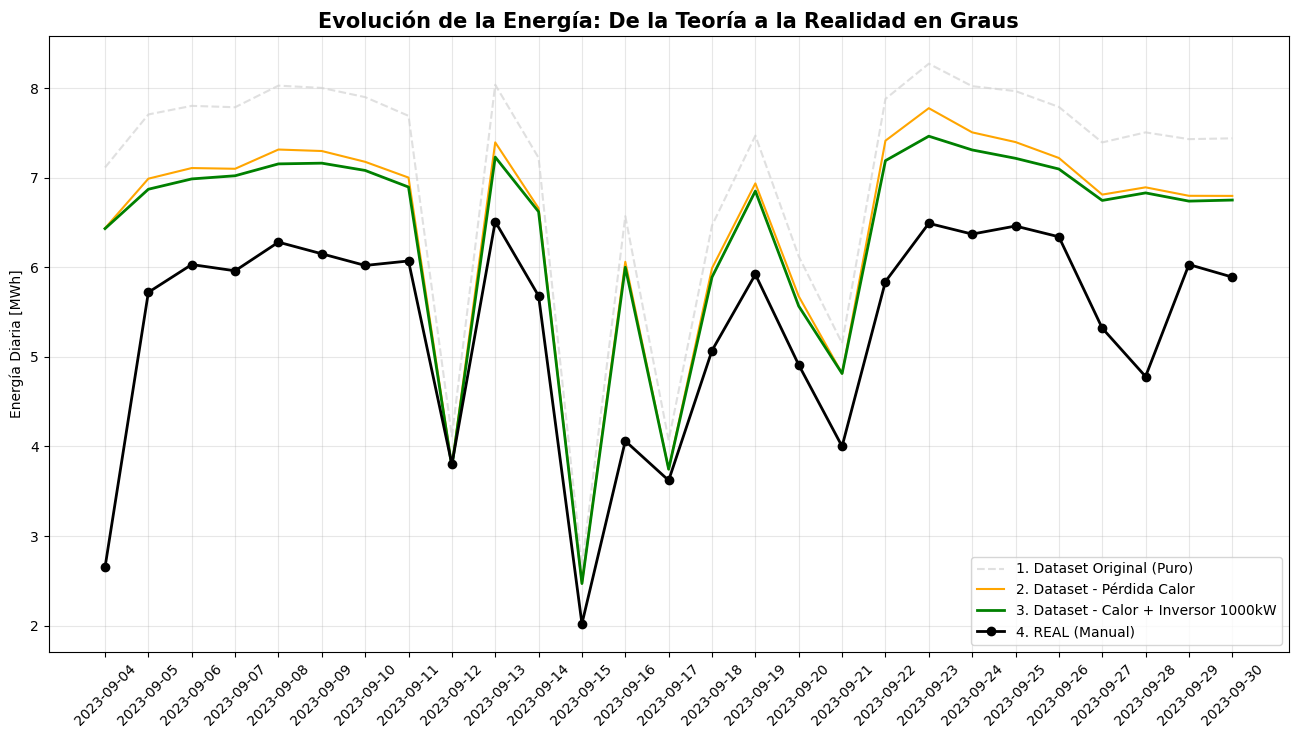

In [7]:
plt.figure(figsize=(16, 8))
plt.plot(df_analisis.index, df_analisis['Dataset_MWh'], label='1. Dataset Original (Puro)', color='lightgray', ls='--', alpha=0.7)
plt.plot(df_analisis.index, df_analisis['Dataset_Menos_Temp_MWh'], label='2. Dataset - Pérdida Calor', color='orange', lw=1.5)
plt.plot(df_analisis.index, df_analisis['Dataset_Inversor_Y_Temp_MWh'], label='3. Dataset - Calor + Inversor 1000kW', color='green', lw=2)
plt.plot(df_analisis.index, df_analisis['Manual_Real_MWh'], label='4. REAL (Manual)', color='black', marker='o', lw=2)

plt.title('Evolución de la Energía: De la Teoría a la Realidad en Graus', fontsize=15, fontweight='bold')
plt.ylabel('Energía Diaria [MWh]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(df_analisis.index, rotation=45)
plt.show()

## 6. Análisis de Curva de Generación Horaria
Para validar el comportamiento del dataset, analizamos un día específico (9 de Septiembre de 2023). Observamos la distribución de potencia a lo largo de las horas de sol y el pico máximo registrado.

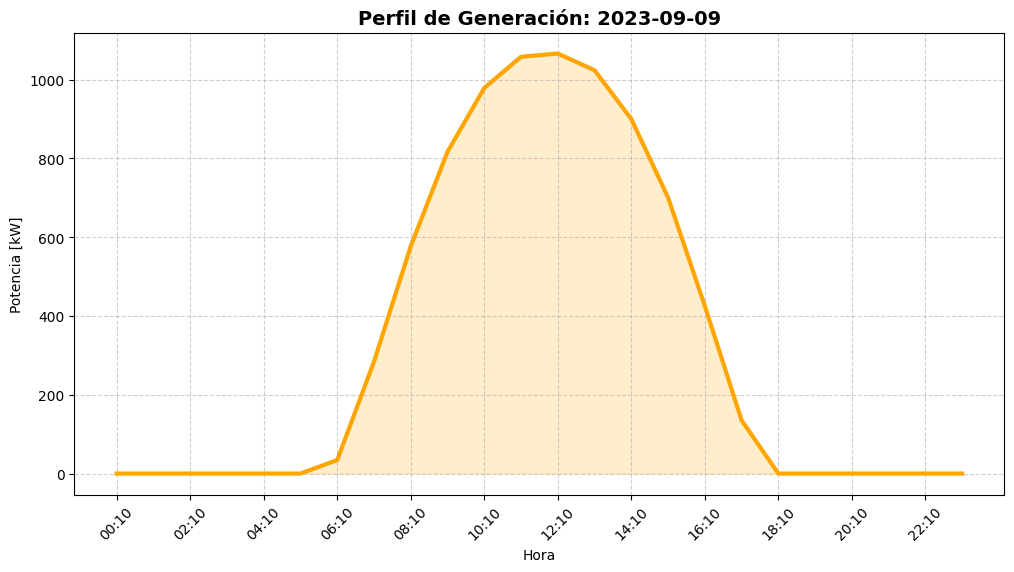

☀️ Pico de potencia máximo registrado: 1066.42 kW


In [8]:
dia_especifico = '2023-09-09'
datos_dia = df.loc[dia_especifico].copy()
datos_dia['Potencia_kW'] = datos_dia['P'] / 1000.0

plt.figure(figsize=(12, 6))
plt.plot(datos_dia.index, datos_dia['Potencia_kW'], color='orange', lw=3, label='Potencia Teórica')
plt.fill_between(datos_dia.index, datos_dia['Potencia_kW'], color='orange', alpha=0.2)

plt.title(f'Perfil de Generación: {dia_especifico}', fontsize=14, fontweight='bold')
plt.xlabel('Hora')
plt.ylabel('Potencia [kW]')
plt.xticks(datos_dia.index[::2], [hora.strftime('%H:%M') for hora in datos_dia.index[::2]], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"☀️ Pico de potencia máximo registrado: {datos_dia['Potencia_kW'].max():.2f} kW")